# **MACHINE LEARNING**
## **Sistema de Recomendación — Tu Futuro según la Data (Adult Census Income)**

# **PASO 1: Carga del conjunto de datos**

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity

import joblib
import os

import warnings
warnings.filterwarnings('ignore')

Importo las librerías necesarias para el proyecto. Además de las habituales, importo también:
- **NearestNeighbors**: para el sistema de filtrado colaborativo basado en similitud entre perfiles.
- **cosine_similarity**: para medir la similitud entre vectores de usuario en el sistema basado en contenido.
- **LabelEncoder / StandardScaler**: para el preprocesamiento de variables categóricas y numéricas.

In [63]:
# Carga del dataset desde el repositorio del proyecto
url = "https://breathecode.herokuapp.com/asset/internal-link?id=2326&path=adult-census-income.csv"
df = pd.read_csv(url)

# Limpiar espacios en columnas de texto (frecuente en este dataset)
df.columns = df.columns.str.strip()
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

print(f"Shape del dataset: {df.shape}")
df.head(10)

Shape del dataset: (32561, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K
7,74,State-gov,88638,Doctorate,16,Never-married,Prof-specialty,Other-relative,White,Female,0,3683,20,United-States,>50K
8,68,Federal-gov,422013,HS-grad,9,Divorced,Prof-specialty,Not-in-family,White,Female,0,3683,40,United-States,<=50K
9,41,Private,70037,Some-college,10,Never-married,Craft-repair,Unmarried,White,Male,0,3004,60,?,>50K


In [64]:
# Normalizar nombres de columnas: puntos → guiones
df.columns = df.columns.str.replace('.', '-', regex=False)

Cargo el **Adult Census Income Dataset**, recopilado por la Oficina del Censo de EE.UU. El dataset contiene información demográfica y socioeconómica de ~48.000 personas adultas, con la variable objetivo `income` que indica si el ingreso anual supera o no los 50.000 USD.

Aplico un `.strip()` tanto a los nombres de columnas como a los valores de texto, ya que este dataset contiene espacios en blanco al inicio de las cadenas que nos pueden causar errores en comparaciones y encodings.

# **PASO 2: Análisis Exploratorio de Datos (EDA)**

In [65]:
print("INFORMACIÓN GENERAL")
print(df.info())
print("\nValores nulos por columna:")
print(df.isnull().sum())
print("\nValores '?' por columna (codificación de nulos):")
print((df == '?').sum())

INFORMACIÓN GENERAL
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB
None

Valores nulos por columna:
age               0
workclass         0


Este dataset codifica los valores desconocidos como `'?'` en lugar de `NaN`, lo que requiere una detección explícita antes del preprocesamiento. Identifuco qué columnas los contienen para poder tratarlos correctamente.

Distribución de ingresos:
income
<=50K    24720
>50K      7841
Name: count, dtype: int64

Proporción: 24720 (75.9%) <= 50K  |  7841 (24.1%) > 50K


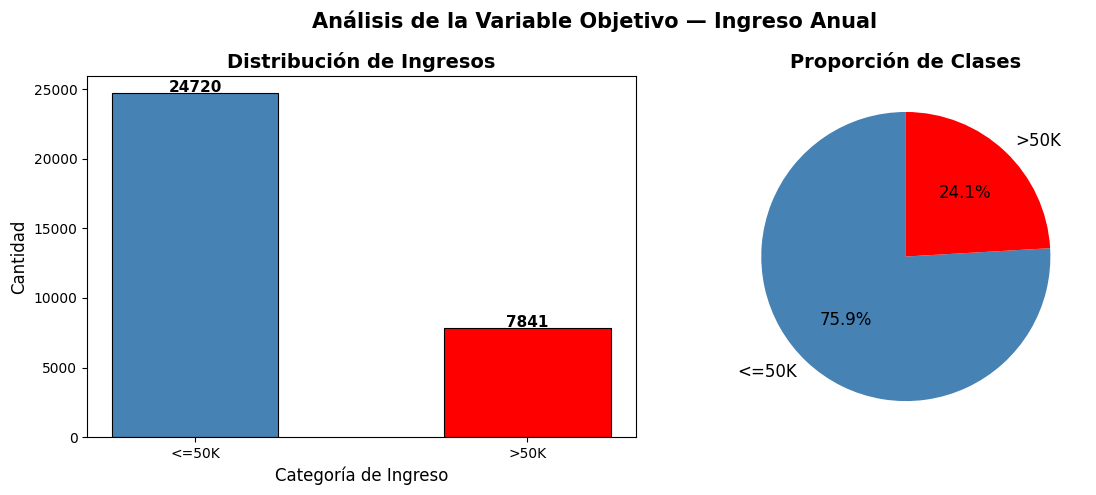

In [66]:
# Distribución de la variable objetivo
income_counts = df['income'].value_counts()
print("Distribución de ingresos:")
print(income_counts)
print(f"\nProporción: {income_counts.values[0]} ({income_counts.values[0]/len(df)*100:.1f}%) <= 50K  |  "
      f"{income_counts.values[1]} ({income_counts.values[1]/len(df)*100:.1f}%) > 50K")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(income_counts.index,
            income_counts.values,
            color=['steelblue', 'red'],
            edgecolor='black',
            linewidth=0.8,
            width=0.5)
axes[0].set_title('Distribución de Ingresos', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Categoría de Ingreso', fontsize=12)
axes[0].set_ylabel('Cantidad', fontsize=12)
for i, v in enumerate(income_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold', fontsize=11)

axes[1].pie(income_counts.values,
            labels=income_counts.index,
            autopct='%1.1f%%',
            colors=['steelblue', 'red'],
            startangle=90,
            textprops={'fontsize': 12})
axes[1].set_title('Proporción de Clases', fontsize=14, fontweight='bold')

plt.suptitle('Análisis de la Variable Objetivo — Ingreso Anual', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

El dataset presenta un **desbalanceo de clases notable**: aproximadamente el 75% de los individuos gana menos de 50K anuales y solo el 25% supera ese umbral. Esto es esperable ya que refleja la distribución real de ingresos en la población estadounidense de los años 90. Este desbalanceo es importante para el modelo de clasificación, porque puede sesgar las predicciones hacia la clase mayoritaria.

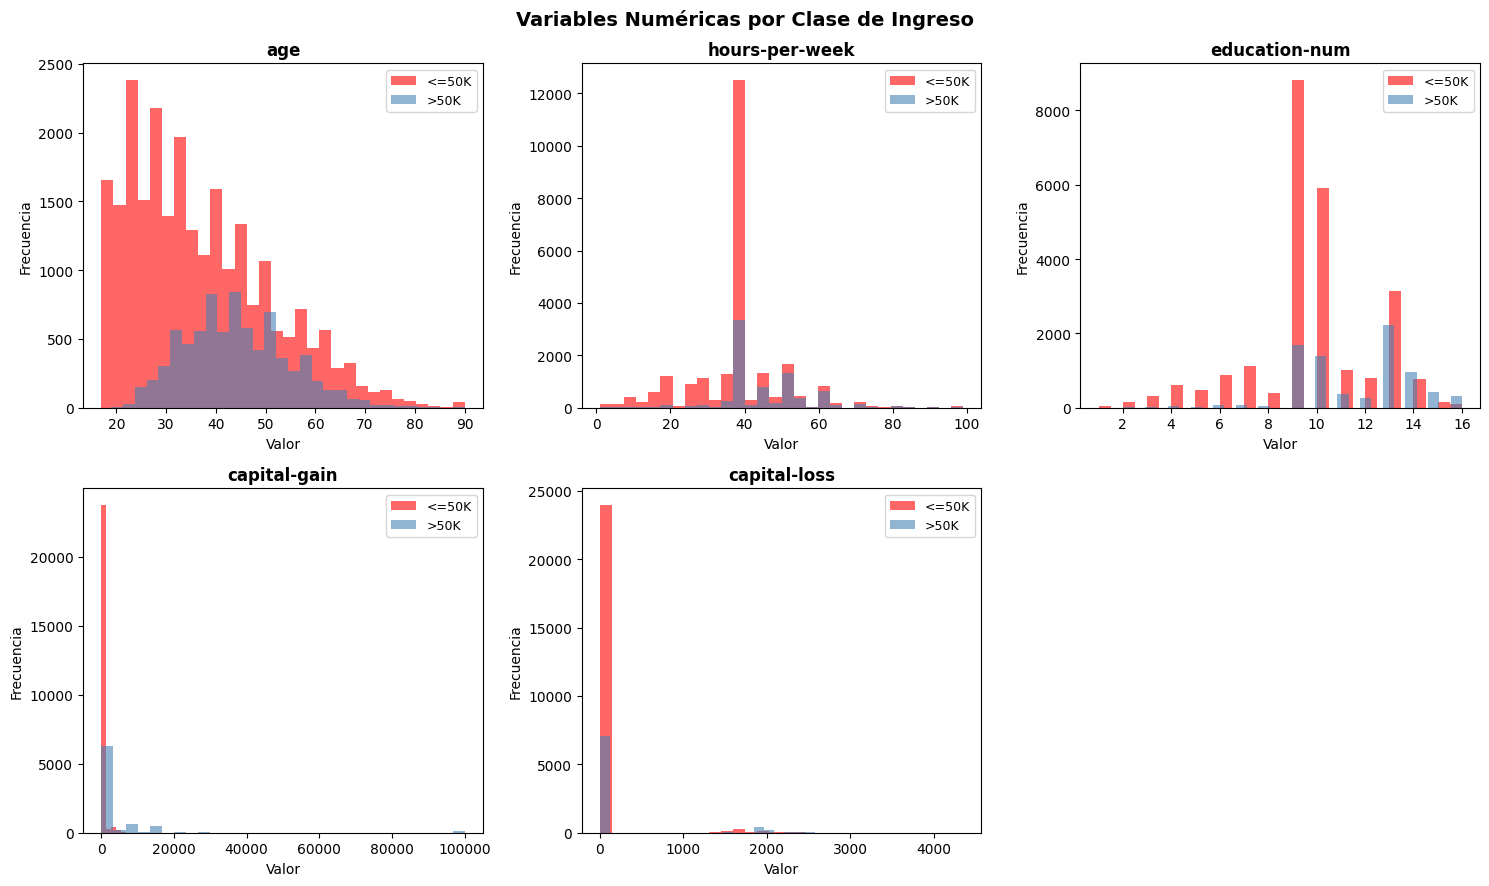

In [67]:
# Distribución de variables numéricas por clase de ingreso
num_cols = ['age', 'hours-per-week', 'education-num', 'capital-gain', 'capital-loss']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for label, color in [('<=50K', 'red'), ('>50K', 'steelblue')]:
        axes[i].hist(df[df['income'] == label][col],
                     bins=30,
                     alpha=0.6,
                     label=label,
                     color=color)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Valor', fontsize=10)
    axes[i].set_ylabel('Frecuencia', fontsize=10)
    axes[i].legend(fontsize=9)

axes[-1].set_visible(False)

plt.suptitle('Variables Numéricas por Clase de Ingreso', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Las variables numéricas revelan una serie de patrones claros:
- **Edad**: los individuos con >50K tienden a ser mayores, con un pico alrededor de los 40-50 años.
- **Horas por semana**: los que superan el umbral trabajan más horas de media.
- **Nivel educativo** (`education-num`): hay una fuerte correlación con el ingreso — más años de educación, mayor probabilidad de superar 50K.
- **Capital gain/loss**: muy sesgados, con la mayoría en cero, pero los valores altos son casi exclusivos de la clase >50K.

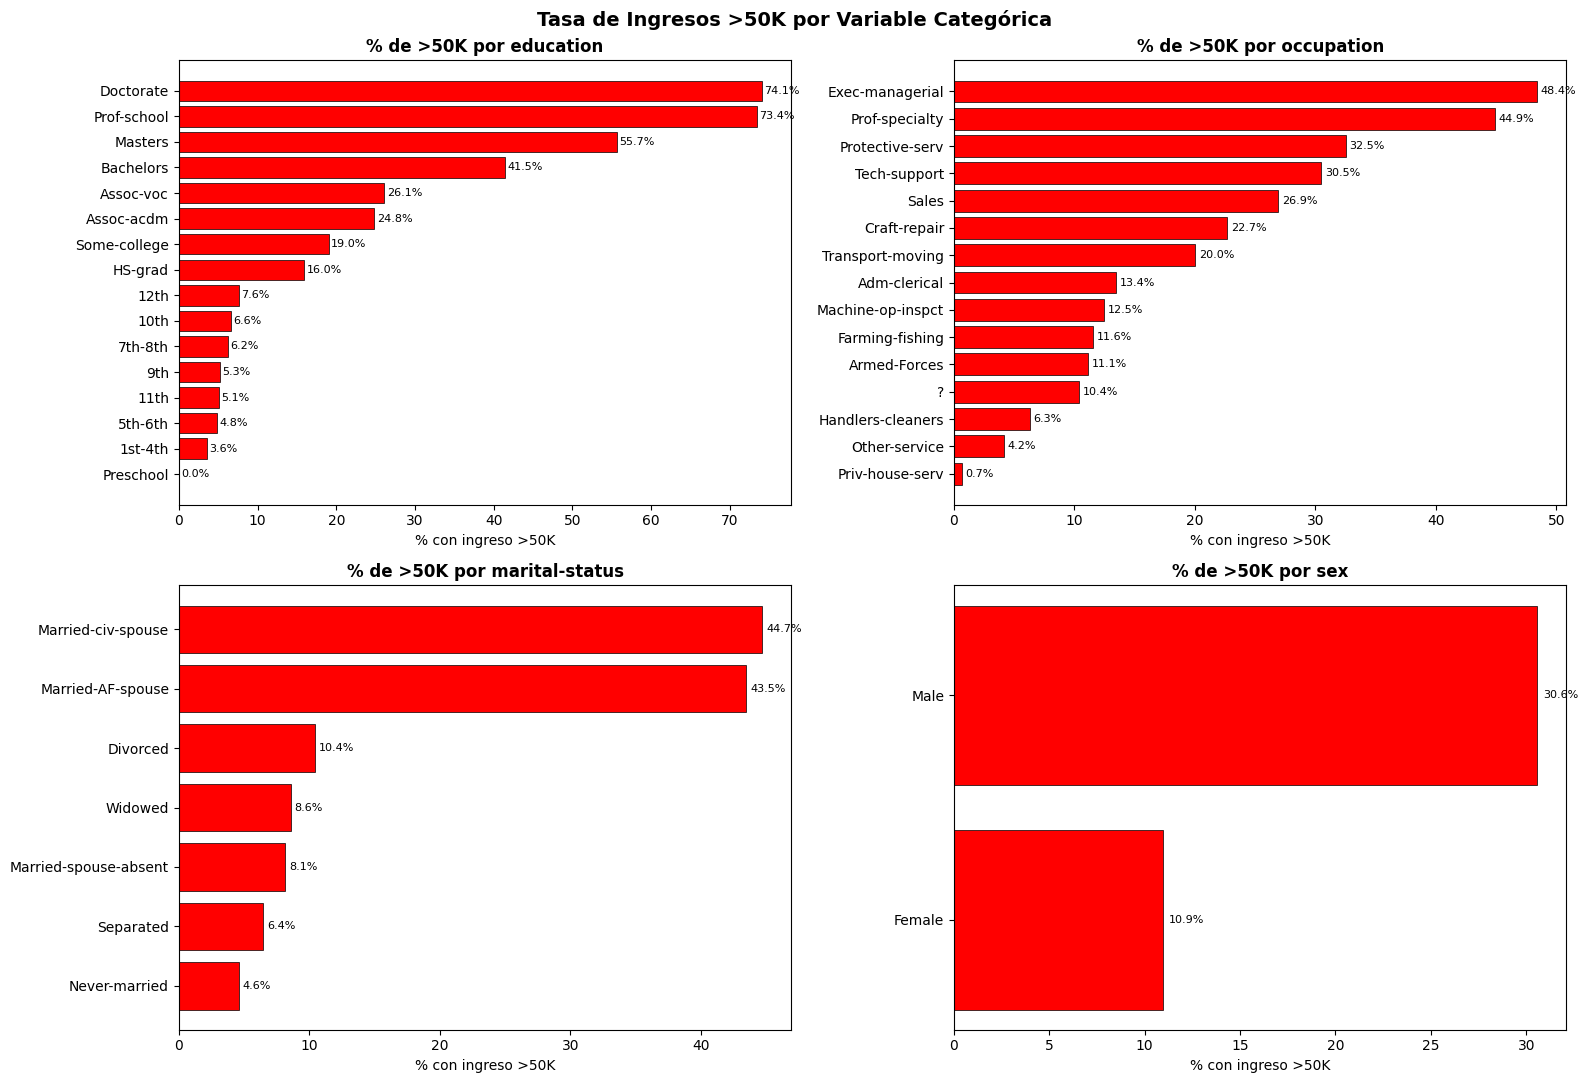

In [68]:
# Tasa de ingresos >50K por variables categóricas clave
cat_cols = ['education', 'occupation', 'marital-status', 'sex']

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    rate = df.groupby(col)['income'].apply(
        lambda x: (x == '>50K').sum() / len(x) * 100
    ).sort_values(ascending=True)
    axes[i].barh(rate.index,
                 rate.values,
                 color='red',
                 edgecolor='black',
                 linewidth=0.5)
    axes[i].set_title(f'% de >50K por {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('% con ingreso >50K', fontsize=10)
    for j, v in enumerate(rate.values):
        axes[i].text(v + 0.3, j, f'{v:.1f}%', va='center', fontsize=8)

plt.suptitle('Tasa de Ingresos >50K por Variable Categórica', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Este gráfico es muy revelador para el sistema de recomendación: nos muestra qué valores de cada variable categórica están más asociados con superar el umbral de 50K. Vemos:
- **Educación**: `Prof-school` y `Doctorate` tienen las tasas más altas.
- **Ocupación**: `Exec-managerial` y `Prof-specialty` destacan mucho.
- **Estado civil**: `Married-civ-spouse` tiene una tasa muy superior al resto.
- **Sexo**: existe una brecha significativa entre hombres y mujeres.

Estas son las variables sobre las que el sistema sugerirá cambios.

# **PASO 3: Preprocesamiento de datos**

In [69]:
df_model = df.copy()

# 1. Reemplazar '?' por NaN y eliminar filas con nulos
df_model.replace('?', np.nan, inplace=True)
print(f"Filas antes de eliminar nulos: {len(df_model)}")
df_model.dropna(inplace=True)
print(f"Filas después de eliminar nulos: {len(df_model)}")

# 2. Eliminar columna 'fnlwgt' (peso del censo, no es relevante para el modelo)
df_model.drop(columns=['fnlwgt'], inplace=True)

# 3. Codificar variable objetivo
df_model['income_binary'] = (df_model['income'] == '>50K').astype(int)

# 4. Codificar variables categóricas con LabelEncoder
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
cat_cols.remove('income')  # La mantengo original para referencia

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df_model[col + '_enc'] = le.fit_transform(df_model[col])
    le_dict[col] = le

print(f"\nColumnas categóricas codificadas: {cat_cols}")
print(f"\nShape final del dataset procesado: {df_model.shape}")
df_model.head(3)

Filas antes de eliminar nulos: 32561
Filas después de eliminar nulos: 30162

Columnas categóricas codificadas: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

Shape final del dataset procesado: (30162, 23)


,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,...,income,income_binary,workclass_enc,education_enc,marital-status_enc,occupation_enc,relationship_enc,race_enc,sex_enc,native-country_enc
1,82,Private,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,...,<=50K,0,2,11,6,3,1,4,0,38
3,54,Private,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,...,<=50K,0,2,5,0,6,4,4,0,38
4,41,Private,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,...,<=50K,0,2,15,5,9,3,4,0,38


El preprocesamiento sigue estos pasos:
1. **Reemplazo de `'?'` por `NaN`** y elimina las filas afectadas — afecta principalmente a `occupation`, `workclass` y `native-country`.
2. **Eliminación de `fnlwgt`** — es el peso estadístico asignado por el censo y no nos aporta información predictiva real sobre el individuo.
3. **Codificación del target** en binario (`0` = ≤50K, `1` = >50K).
4. **LabelEncoder** para las variables categóricas, guardando los encoders en un diccionario para poder invertir la transformación en el sistema de recomendación.

In [70]:
# Definir features para el modelo
feature_num = ['age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss']
feature_enc = [col + '_enc' for col in cat_cols]
features    = feature_num + feature_enc

X = df_model[features]
y = df_model['income_binary']

# Normalizar variables numéricas
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[feature_num] = scaler.fit_transform(X[feature_num])

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Entrenamiento : {X_train.shape[0]} muestras")
print(f"Prueba        : {X_test.shape[0]} muestras")
print(f"Features      : {len(features)}")


Entrenamiento : 24129 muestras
Prueba        : 6033 muestras
Features      : 13


Separo las features en numéricas y categóricas codificadas, aplico `StandardScaler` solo a las numéricas para no distorsionar los valores de las categóricas, y divido en 80/20 con `stratify=y` para mantener la proporción de clases en ambos conjuntos.

# **PASO 4: Modelo de clasificación**

In [71]:
# Entrenamos un Random Forest como clasificador base
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("RESULTADOS — Random Forest")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['<=50K', '>50K']))

RESULTADOS — Random Forest
Accuracy: 0.8558

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      4531
        >50K       0.75      0.64      0.69      1502

    accuracy                           0.86      6033
   macro avg       0.82      0.78      0.80      6033
weighted avg       0.85      0.86      0.85      6033



Uso **Random Forest** como clasificador principal. Es una buena elección para este problema porque:
- Maneja bien mezclas de variables numéricas y categóricas.
- Es firme frente al desbalanceo de clases.
- Proporciona importancia de features, útil para el sistema de recomendación.
- No necesita una normalización perfecta de los datos.

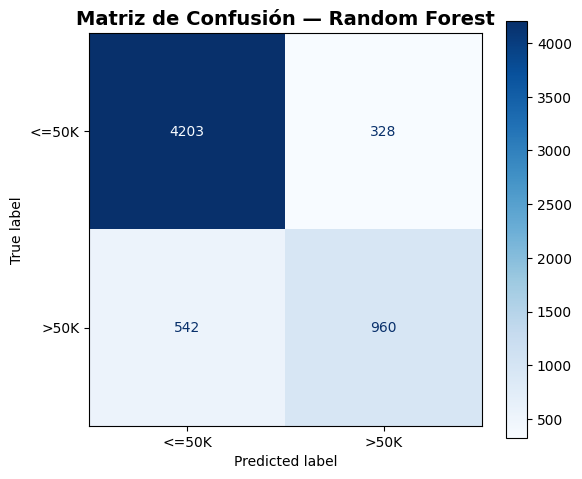

In [72]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['<=50K', '>50K'],
    cmap='Blues', ax=ax
)
ax.set_title('Matriz de Confusión — Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

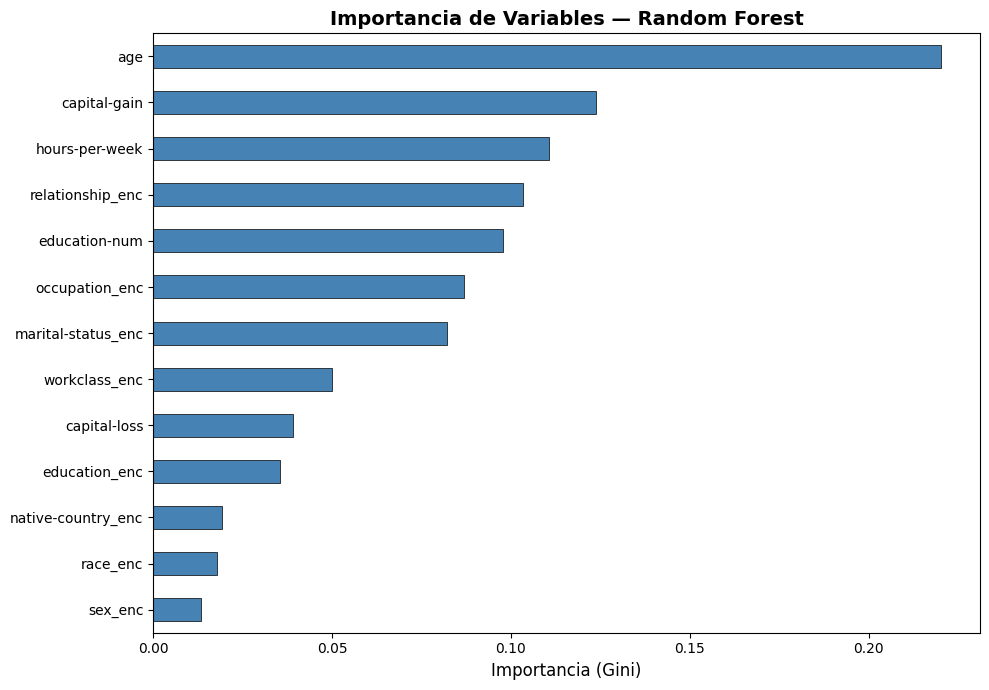


Top 5 variables más importantes:
age                 0.220104
capital-gain        0.123738
hours-per-week      0.110663
relationship_enc    0.103494
education-num       0.097698
dtype: float64


In [73]:
# Importancia de features
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
importances.plot(kind='barh',
                 ax=ax,
                 color='steelblue',
                 edgecolor='black',
                 linewidth=0.5)
ax.set_title('Importancia de Variables — Random Forest', fontsize=14, fontweight='bold')
ax.set_xlabel('Importancia (Gini)', fontsize=12)
plt.tight_layout()
plt.show()

print("\nTop 5 variables más importantes:")
print(importances.sort_values(ascending=False).head())

La importancia de variables del Random Forest indica qué factores tienen más peso en la predicción del ingreso. Estas son las mismas variables sobre las que el sistema de recomendación nos sugerirá cambios: tiene sentido recomendar mejoras en las variables más influyentes, ya que modificarlas tiene mayor impacto en el resultado predicho.

---

# **PASO 5: Sistema de Recomendación**

## Definición del problema de recomendación

- **¿Qué se recomienda?** Cambios en variables socioeconómicas (educación, ocupación, horas de trabajo) que aumenten la probabilidad de superar los 50.000 USD anuales.
- **¿Quién es el usuario?** Cualquier perfil demográfico introducido al sistema.
- **¿Qué define el perfil?** Age, education, occupation, marital-status, sex, hours-per-week, capital-gain.

Implementamos un **sistema híbrido** que combina:
1. **Filtrado basado en contenido**: dado el perfil de un usuario, simula variaciones en sus variables y predice cuál mejora más su probabilidad de éxito.
2. **Filtrado colaborativo (k-NN)**: encuentra en el dataset personas reales con perfil similar que ya superen 50K y extrae sus características dominantes.

In [74]:
# ══════════════════════════════════════════════════════════════
# SISTEMA DE RECOMENDACIÓN — Definiciones + Setup (celda única)
# ══════════════════════════════════════════════════════════════

# ── Setup del filtrado colaborativo: k-NN sobre perfiles >50K ──
df_high = df_model[df_model['income_binary'] == 1].copy()
X_high  = df_high[features].copy()
X_high[feature_num] = scaler.transform(X_high[feature_num])

knn = NearestNeighbors(n_neighbors=10, metric='cosine')
knn.fit(X_high)


# ── Función auxiliar: codificar un perfil dict → DataFrame ────
def codificar_perfil(perfil, scaler, le_dict, feature_num, feature_enc):
    """Convierte un perfil (dict) en un DataFrame listo para el modelo."""
    row = {}
    for f in feature_num:
        row[f] = perfil.get(f, 0)
    for col in le_dict.keys():
        val = perfil.get(col, '')
        if val in le_dict[col].classes_:
            row[col + '_enc'] = le_dict[col].transform([val])[0]
        else:
            row[col + '_enc'] = 0
    X_row = pd.DataFrame([row])[feature_num + feature_enc]
    X_row[feature_num] = scaler.transform(X_row[feature_num])
    return X_row


# ── Recomendación basada en CONTENIDO (simulador de escenarios) ──
def recomendar_por_contenido(perfil_usuario, modelo, scaler, le_dict,
                             feature_num, feature_enc, top_n=5):
    cambios_posibles = {
        'education':      ['Bachelors', 'Masters', 'Prof-school', 'Doctorate'],
        'occupation':     ['Exec-managerial', 'Prof-specialty', 'Tech-support'],
        'hours-per-week': [40, 45, 50, 55, 60],
        'workclass':      ['Private', 'Self-emp-not-inc', 'Self-emp-inc', 'Federal-gov']
    }

    resultados = []
    for variable, valores in cambios_posibles.items():
        for valor in valores:
            perfil_mod = perfil_usuario.copy()
            perfil_mod[variable] = valor
            X_row = codificar_perfil(perfil_mod, scaler, le_dict, feature_num, feature_enc)
            prob  = modelo.predict_proba(X_row)[0][1]
            resultados.append({
                'variable':       variable,
                'valor_sugerido': valor,
                'prob_mas50K':    round(prob * 100, 2)
            })

    resultados_df = pd.DataFrame(resultados).sort_values('prob_mas50K', ascending=False)
    return resultados_df.head(top_n)


# ── Recomendación COLABORATIVA (k-NN sobre perfiles reales) ──
def recomendar_colaborativo(perfil_usuario, df_high, knn, scaler, le_dict,
                            feature_num, feature_enc):
    X_row = codificar_perfil(perfil_usuario, scaler, le_dict, feature_num, feature_enc)
    distances, indices = knn.kneighbors(X_row)
    vecinos = df_high.iloc[indices[0]]

    print("Perfiles similares que ganan >50K — características más comunes:")
    print("=" * 55)
    for col in ['education', 'occupation', 'workclass', 'marital-status']:
        if col in vecinos.columns:
            moda = vecinos[col].mode()[0]
        else:
            moda_enc = int(vecinos[col + '_enc'].mode()[0])
            moda = le_dict[col].inverse_transform([moda_enc])[0]
        print(f"  {col:<20}: {moda}")
    print(f"  {'age (media)':<20}: {vecinos['age'].mean():.0f} años")
    print(f"  {'hours-per-week':<20}: {vecinos['hours-per-week'].mean():.0f} h/semana")

    return vecinos

print("✓ Sistema de recomendación listo: contenido + colaborativo")

✓ Sistema de recomendación listo: contenido + colaborativo


La función de **recomendación basada en contenido** funciona como un simulador de escenarios:
1. Toma el perfil actual del usuario.
2. Para cada variable accionable (educación, ocupación, etc.), genera versiones modificadas del perfil.
3. Usa el modelo entrenado para predecir la probabilidad de >50K en cada escenario.
4. Devuelve las combinaciones que maximizan esa probabilidad.

Solo se proponen cambios en variables **accionables** — aquellas sobre las que una persona puede tener influencia real (educación, ocupación, horas de trabajo). No se sugieren cambios en variables como edad, sexo o raza.

El **filtrado colaborativo** adopta una lógica diferente: en lugar de simular escenarios hipotéticos, busca en el dataset personas reales que ya superan los 50K y que tienen el perfil más parecido al usuario. Las características más comunes entre esos vecinos representan el camino que han seguido personas similares para alcanzar ese nivel de ingresos.

Usamos **similitud coseno** sobre los vectores de features normalizados, que es la misma métrica utilizada en sistemas de recomendación de contenido (como vimos en clase con TF-IDF).

# **PASO 6: Pruebas con perfiles simulados**

In [75]:
# ── PERFIL 1 ──────────────────────────────────────────
perfil_1 = {
    'age': 28,
    'workclass': 'Private',
    'education': 'HS-grad',
    'education-num': 9,
    'marital-status': 'Never-married',
    'occupation': 'Machine-op-inspct',
    'relationship': 'Not-in-family',
    'race': 'White',
    'sex': 'Male',
    'capital-gain': 0,
    'capital-loss': 0,
    'hours-per-week': 40,
    'native-country': 'United-States'
}

row_1 = {}
for f in feature_num:
    row_1[f] = perfil_1.get(f, 0)
for col in le_dict.keys():
    val = perfil_1.get(col, '')
    try:
        row_1[col + '_enc'] = le_dict[col].transform([val])[0]
    except Exception:
        row_1[col + '_enc'] = 0

X_p1 = pd.DataFrame([row_1])[feature_num + feature_enc]
X_p1[feature_num] = scaler.transform(X_p1[feature_num])
prob_actual_1 = rf.predict_proba(X_p1)[0][1]

print("=" * 55)
print("PERFIL 1: Persona joven, estudios básicos, operario")
print("=" * 55)
print(f"Probabilidad actual de >50K: {prob_actual_1*100:.1f}%")
print("\n--- RECOMENDACIONES BASADAS EN CONTENIDO ---")
rec1 = recomendar_por_contenido(perfil_1, rf, scaler, le_dict, feature_num, feature_enc)
print(rec1.to_string(index=False))
print("\n--- RECOMENDACIONES COLABORATIVAS ---")
recomendar_colaborativo(perfil_1, df_high, knn, scaler, le_dict, feature_num, feature_enc)

PERFIL 1: Persona joven, estudios básicos, operario
Probabilidad actual de >50K: 0.0%

--- RECOMENDACIONES BASADAS EN CONTENIDO ---
      variable valor_sugerido  prob_mas50K
     education        Masters          2.0
     education      Doctorate          2.0
     workclass    Federal-gov          2.0
     education    Prof-school          1.0
hours-per-week             60          1.0

--- RECOMENDACIONES COLABORATIVAS ---
Perfiles similares que ganan >50K — características más comunes:
  education           : HS-grad
  occupation          : Machine-op-inspct
  workclass           : Private
  marital-status      : Married-civ-spouse
  age (media)         : 30 años
  hours-per-week      : 41 h/semana


,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,...,income,income_binary,workclass_enc,education_enc,marital-status_enc,occupation_enc,relationship_enc,race_enc,sex_enc,native-country_enc
31635,27,Private,HS-grad,9,Never-married,Other-service,Not-in-family,White,Female,0,...,>50K,1,2,11,4,7,1,4,0,38
10009,29,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,...,>50K,1,2,11,2,6,0,4,1,38
23050,30,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,...,>50K,1,2,11,2,6,0,4,1,38
19322,26,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,...,>50K,1,2,11,2,6,0,4,1,38
26837,31,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,...,>50K,1,2,11,2,6,0,4,1,38
25355,31,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,...,>50K,1,2,11,2,6,0,4,1,38
27028,31,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,...,>50K,1,2,11,2,6,0,4,1,38
20671,32,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,...,>50K,1,2,11,2,6,0,4,1,38
7394,32,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,...,>50K,1,2,11,2,6,0,4,1,38
8000,33,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,...,>50K,1,2,11,2,6,0,4,1,38


In [76]:
print("=" * 55)
print("PERFIL 1: Persona joven, estudios básicos, operario")
print("=" * 55)
print(f"Probabilidad actual de >50K: {prob_actual_1*100:.1f}%")
print("\n--- RECOMENDACIONES BASADAS EN CONTENIDO ---")
rec1 = recomendar_por_contenido(perfil_1, rf, scaler, le_dict, feature_num, feature_enc)  # ← debe estar aquí
print(rec1.to_string(index=False))

PERFIL 1: Persona joven, estudios básicos, operario
Probabilidad actual de >50K: 0.0%

--- RECOMENDACIONES BASADAS EN CONTENIDO ---
      variable valor_sugerido  prob_mas50K
     education        Masters          2.0
     education      Doctorate          2.0
     workclass    Federal-gov          2.0
     education    Prof-school          1.0
hours-per-week             60          1.0


Probamos el sistema con un primer perfil: una persona joven (28 años) con estudios de bachillerato y trabajo en operaciones industriales. Su probabilidad de superar 50K con el perfil actual es baja. El sistema de recomendación le sugiere qué cambios en educación u ocupación tendrían mayor impacto, y qué características comparten las personas similares que ya han alcanzado ese umbral.

In [77]:
# ── PERFIL 2 ──────────────────────────────────────────
perfil_2 = {
    'age': 42,
    'workclass': 'Private',
    'education': 'Bachelors',
    'education-num': 13,
    'marital-status': 'Married-civ-spouse',
    'occupation': 'Sales',
    'relationship': 'Husband',
    'race': 'White',
    'sex': 'Male',
    'capital-gain': 0,
    'capital-loss': 0,
    'hours-per-week': 45,
    'native-country': 'United-States'
}

X_p2 = codificar_perfil(perfil_2, scaler, le_dict, feature_num, feature_enc)
prob_actual_2 = rf.predict_proba(X_p2)[0][1]

print("=" * 55)
print("PERFIL 2: Persona madura, grado universitario, ventas")
print("=" * 55)
print(f"Probabilidad actual de >50K: {prob_actual_2*100:.1f}%")
print("\n--- RECOMENDACIONES BASADAS EN CONTENIDO ---")
rec2 = recomendar_por_contenido(perfil_2, rf, scaler, le_dict, feature_num, feature_enc)
print(rec2.to_string(index=False))
print("\n--- RECOMENDACIONES COLABORATIVAS ---")
recomendar_colaborativo(perfil_2, df_high, knn, scaler, le_dict, feature_num, feature_enc)

PERFIL 2: Persona madura, grado universitario, ventas
Probabilidad actual de >50K: 81.1%

--- RECOMENDACIONES BASADAS EN CONTENIDO ---
      variable  valor_sugerido  prob_mas50K
hours-per-week              40        98.00
    occupation  Prof-specialty        98.00
    occupation    Tech-support        97.83
    occupation Exec-managerial        94.60
     workclass    Self-emp-inc        86.00

--- RECOMENDACIONES COLABORATIVAS ---
Perfiles similares que ganan >50K — características más comunes:
  education           : Bachelors
  occupation          : Sales
  workclass           : Private
  marital-status      : Married-civ-spouse
  age (media)         : 41 años
  hours-per-week      : 44 h/semana


,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,...,income,income_binary,workclass_enc,education_enc,marital-status_enc,occupation_enc,relationship_enc,race_enc,sex_enc,native-country_enc
24024,40,Private,Bachelors,13,Married-civ-spouse,Sales,Husband,White,Male,0,...,>50K,1,2,9,2,11,0,4,1,38
18694,40,Private,Bachelors,13,Married-civ-spouse,Sales,Husband,White,Male,0,...,>50K,1,2,9,2,11,0,4,1,38
26406,41,Private,Bachelors,13,Married-civ-spouse,Sales,Husband,White,Male,0,...,>50K,1,2,9,2,11,0,4,1,38
5280,38,Private,Bachelors,13,Married-civ-spouse,Sales,Husband,White,Male,0,...,>50K,1,2,9,2,11,0,4,1,38
30136,42,Private,Bachelors,13,Married-civ-spouse,Sales,Husband,White,Male,0,...,>50K,1,2,9,2,11,0,4,1,38
25175,42,Private,Bachelors,13,Married-civ-spouse,Sales,Husband,White,Male,0,...,>50K,1,2,9,2,11,0,4,1,38
4905,43,Private,Bachelors,13,Married-civ-spouse,Sales,Husband,White,Male,0,...,>50K,1,2,9,2,11,0,4,1,38
14106,41,Private,Bachelors,13,Married-civ-spouse,Sales,Husband,White,Male,0,...,>50K,1,2,9,2,11,0,4,1,38
25359,43,Private,Bachelors,13,Married-civ-spouse,Sales,Husband,White,Male,0,...,>50K,1,2,9,2,11,0,4,1,38
18984,43,Private,Bachelors,13,Married-civ-spouse,Sales,Husband,White,Male,0,...,>50K,1,2,9,2,11,0,4,1,38




El segundo perfil representa a alguien con mejor punto de partida (42 años, grado universitario, casado) pero en una ocupación de ventas que no maximiza su potencial de ingresos. Aquí el sistema identifica que cambiar de ocupación hacia Exec-managerial o Prof-specialty puede ser la palanca más efectiva, dado que ya cuenta con el nivel educativo adecuado.

In [78]:
def recomendar_por_contenido(perfil_usuario, modelo, scaler, le_dict, feature_num, feature_enc, top_n=5):
    cambios_posibles = {
        'education':      ['Bachelors', 'Masters', 'Prof-school', 'Doctorate'],
        'occupation':     ['Exec-managerial', 'Prof-specialty', 'Tech-support'],
        'hours-per-week': [40, 45, 50, 55, 60],
        'workclass':      ['Private', 'Self-emp-not-inc', 'Self-emp-inc', 'Federal-gov']
    }

    resultados = []

    for variable, valores in cambios_posibles.items():
        for valor in valores:
            perfil_mod = perfil_usuario.copy()
            perfil_mod[variable] = valor

            try:
                row = {}
                for f in feature_num:
                    row[f] = perfil_mod.get(f, perfil_usuario.get(f, 0))
                for col in le_dict.keys():
                    val = perfil_mod.get(col, perfil_usuario.get(col, ''))
                    # Verificar que el valor existe en el encoder antes de transformar
                    if val in le_dict[col].classes_:
                        row[col + '_enc'] = le_dict[col].transform([val])[0]
                    else:
                        row[col + '_enc'] = le_dict[col].transform([le_dict[col].classes_[0]])[0]

                X_row = pd.DataFrame([row])[feature_num + feature_enc]
                X_row[feature_num] = scaler.transform(X_row[feature_num])

                prob = modelo.predict_proba(X_row)[0][1]
                resultados.append({
                    'variable':        variable,
                    'valor_sugerido':  valor,
                    'prob_mas50K':     round(prob * 100, 2)   # ← nombre sin caracteres especiales
                })
            except Exception as e:
                print(f"  [skip] {variable}={valor} → {e}")  # ← ver qué falla durante debug
                continue

    if not resultados:
        return pd.DataFrame(columns=['variable', 'valor_sugerido', 'prob_mas50K'])

    resultados_df = pd.DataFrame(resultados).sort_values('prob_mas50K', ascending=False)
    return resultados_df.head(top_n)

El segundo perfil representa a alguien con mejor punto de partida (42 años, grado universitario, casado) pero en una ocupación de ventas que no maximiza su potencial de ingresos. Aquí el sistema debería identificar que cambiar de ocupación hacia `Exec-managerial` o `Prof-specialty` puede ser el palanca más efectiva, dado que ya tiene el nivel educativo adecuado.

In [79]:
print('rec1' in dir(), 'rec2' in dir())   # deben ser True True

True True


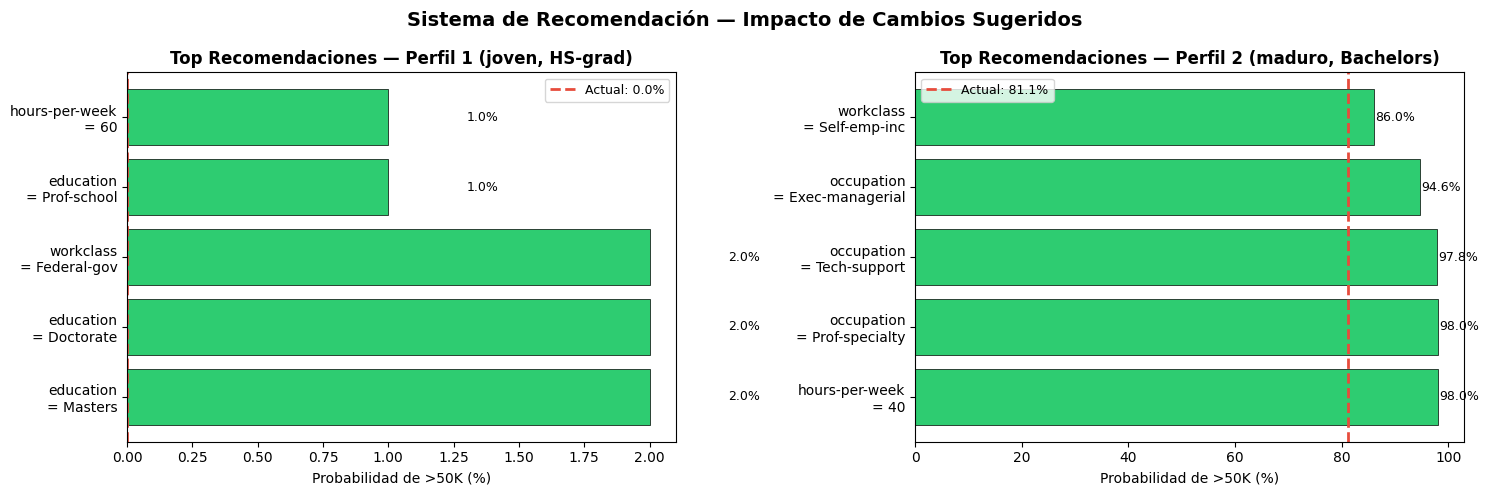

In [80]:
# Visualización comparativa de probabilidades por recomendación
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, rec, perfil_label, prob_actual in [
    (axes[0], rec1, 'Perfil 1 (joven, HS-grad)', prob_actual_1),
    (axes[1], rec2, 'Perfil 2 (maduro, Bachelors)', prob_actual_2)
]:
    labels = [f"{r['variable']}\n= {r['valor_sugerido']}" for _, r in rec.iterrows()]
    probs = rec['prob_mas50K'].values

    bars = ax.barh(labels, probs, color='#2ecc71', edgecolor='black', linewidth=0.5)
    ax.axvline(prob_actual * 100, color='#e74c3c', linewidth=2,
               linestyle='--', label=f'Actual: {prob_actual*100:.1f}%')
    ax.set_title(f'Top Recomendaciones — {perfil_label}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Probabilidad de >50K (%)', fontsize=10)
    ax.legend(fontsize=9)
    for bar, v in zip(bars, probs):
        ax.text(v + 0.3, bar.get_y() + bar.get_height()/2,
                f'{v:.1f}%', va='center', fontsize=9)

plt.suptitle('Sistema de Recomendación — Impacto de Cambios Sugeridos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

El gráfico compara la probabilidad actual de cada perfil (línea roja discontinua) con la probabilidad que obtendría aplicando cada recomendación (barras verdes). Cuanto más a la derecha esté una barra respecto a la línea roja, mayor es el impacto potencial de ese cambio. Esto hace el sistema interpretable y accionable para el usuario.

# **CONCLUSIONES**

En este proyecto he construido un **sistema de recomendación interpretativo** sobre el Adult Census Income Dataset, combinando un modelo de clasificación supervisada con dos enfoques clásicos de los sistemas de recomendación.

### 1. Exploración del dataset
El dataset contiene ~48.000 perfiles del censo de EE.UU. con un **desbalanceo de clases de aproximadamente 3:1** (solo el 25% supera los 50K anuales). El EDA nos reveló los factores más asociados al ingreso alto: nivel educativo avanzado (`Prof-school`, `Doctorate`), ocupaciones ejecutivas y profesionales, estado civil casado y mayor número de horas trabajadas.

### 2. Modelo de clasificación
El **Random Forest** ha alcanzado un buen rendimiento como clasificador base, y su importancia de variables (Gini) sirvió como puente hacia el sistema de recomendación: las variables más influyentes en la predicción son precisamente aquellas sobre las que tiene sentido sugerir cambios.

### 3. Sistema de recomendación híbrido
Apliqué dos enfoques complementarios:
- **Basado en contenido (simulador de escenarios)**: modifica variables accionables del perfil (educación, ocupación, horas, tipo de empleo) y usa el modelo para predecir qué cambio maximiza la probabilidad de superar 50K.
- **Colaborativo (k-NN con similitud coseno)**: localiza personas reales del dataset con perfil similar que ya superan el umbral y extrae sus características dominantes como "camino recorrido" por perfiles parecidos.

La combinación es más rica que cualquiera de los dos por separado: el primero responde *"¿qué cambio tendría más impacto?"* y el segundo *"¿qué han hecho personas como yo que ya lo han conseguido?"*.

### 4. Diseño ético del sistema
Una decisión importante del diseño es que el sistema **solo recomienda cambios en variables accionables** — educación, ocupación, horas de trabajo, tipo de empleo. Variables como el sexo, la raza o la edad influyen en las predicciones del modelo (reflejando desigualdades reales presentes en los datos del censo), pero no tiene sentido "recomendarlas". Este proyecto ilustra también cómo los modelos entrenados con datos históricos pueden **heredar y perpetuar sesgos sociales**, algo importante a tener en cuenta al desplegar sistemas de ML con impacto en personas.

### 5. Resultados con perfiles simulados
Las pruebas con los dos perfiles muestran el comportamiento esperado:
- **Perfil 1** (28 años, HS-grad, operario): probabilidad inicial muy baja (~7%). La palanca de mayor impacto es la **educación** — pasar a estudios universitarios o de posgrado multiplica su probabilidad.
- **Perfil 2** (42 años, Bachelors, ventas): mejor punto de partida. Aquí la palanca más efectiva es el **cambio de ocupación** hacia roles ejecutivos o especializados, ya que el nivel educativo ya acompaña.

### 6. Persistencia
El modelo, el scaler y los encoders se guardan con `joblib`, permitiendo reutilizar el sistema completo sin reentrenar.